In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
#import sklearn  
#import sklearn.datasets  
import scipy.io  
#import os

In [2]:
def load_2D_dataset():  
    data = scipy.io.loadmat('data.mat')  
    train_X = data['X'].T  
    train_Y = data['y'].T  
    test_X = data['Xval'].T  
    test_Y = data['yval'].T  
  
    #plt.scatter(train_X[0, :], train_X[1, :], c=train_Y.ravel(), s=40, cmap=plt.cm.Spectral);  
      
    return train_X, train_Y, test_X, test_Y  


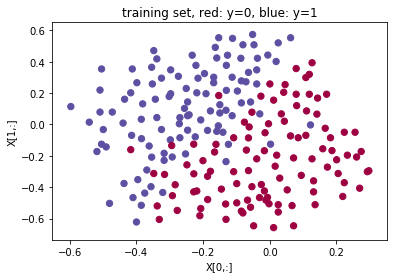

In [3]:
# load dataset circles  
train_X, train_Y, test_X, test_Y = load_2D_dataset()  

plt.scatter(train_X[0, :], train_X[1, :],c=train_Y[0,:], s=40, cmap=plt.cm.Spectral)  
plt.xlabel("X[0,:]")  
plt.ylabel("X[1,:]")  
plt.title("training set, red: y=0, blue: y=1")  
plt.show()  


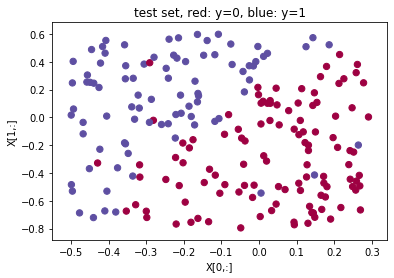

In [4]:
plt.scatter(test_X[0, :], test_X[1, :],c=test_Y[0,:], s=40, cmap=plt.cm.Spectral)  
plt.xlabel("X[0,:]")  
plt.ylabel("X[1,:]")  
plt.title("test set, red: y=0, blue: y=1")  
plt.show()  

#train_X.shape: (2,211), train_Y.shape: (1,211)
#test_X.shape: (2,200), test_Y.shape: (1,200)

In [5]:
def relu(x):  
    """  
    Compute the relu of x  
    Arguments:  
    x -- A scalar or numpy array of any size.  
    Return:  
    s -- relu(x)  
    """  
    s = np.maximum(0,x)  
      
    return s  


In [6]:
def sigmoid(x):  
    """  
    Compute the sigmoid of x  
    Arguments:  
    x -- A scalar or numpy array of any size.  
    Return:  
    s -- sigmoid(x)  
    """  
    s = 1/(1+np.exp(-x))  
    return s  


In [7]:
def forward_propagation(X, parameters):  
    """  
    Implements the forward propagation, without dropout
    this is for test
      
    Arguments:  
    X -- input dataset, of shape (input size, number of examples)  
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3":  
                    W1 -- weight matrix of shape ()  
                    b1 -- bias vector of shape ()  
                    W2 -- weight matrix of shape ()  
                    b2 -- bias vector of shape ()  
                    W3 -- weight matrix of shape ()  
                    b3 -- bias vector of shape ()  
      
    Returns:  
    A3 -- the output
    cache -- internal variables and weights
    """  
          
    # retrieve parameters  
    W1 = parameters["W1"]  
    b1 = parameters["b1"]  
    W2 = parameters["W2"]  
    b2 = parameters["b2"]  
    W3 = parameters["W3"]  
    b3 = parameters["b3"]  
      
    # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID  
    Z1 = np.dot(W1, X) + b1  
    A1 = relu(Z1)  
    Z2 = np.dot(W2, A1) + b2  
    A2 = relu(Z2)  
    Z3 = np.dot(W3, A2) + b3  
    A3 = sigmoid(Z3)  
      
    cache = (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3)  
      
    return A3, cache  


In [8]:
def forward_propagation_with_dropout(X, parameters, keep_prob):  
    """  
    Implements the forward propagation with dropout
    keep_prob = 1 for no dropout
      
    Arguments:  
    X -- input dataset, of shape (input size, number of examples)  
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3":  
                    W1 -- weight matrix of shape ()  
                    b1 -- bias vector of shape ()  
                    W2 -- weight matrix of shape ()  
                    b2 -- bias vector of shape ()  
                    W3 -- weight matrix of shape ()  
                    b3 -- bias vector of shape ()  
    keep_prob - probability of keeping a neuron active during dropout, scalar  
    Returns:  
    A3 -- last activation value, output of the forward propagation, of shape(1,1)   
    cache -- tuple, information stored for computing the backward propagation  
    """  
    np.random.seed(4)       
    # retrieve parameters  
    W1 = parameters["W1"]  
    b1 = parameters["b1"]  
    W2 = parameters["W2"]  
    b2 = parameters["b2"]  
    W3 = parameters["W3"]  
    b3 = parameters["b3"]  
      
    # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID  
    Z1 = np.dot(W1, X) + b1  
    A1 = relu(Z1)  
    ### randomly drop out in layer 1 ###  
    D1 = np.random.rand(A1.shape[0], A1.shape[1])  
    D1 = (D1<keep_prob)  
    A1 = np.multiply(A1,D1)  
    A1 = A1/keep_prob  
    ## end code   
    
    
    Z2 = np.dot(W2, A1) + b2  
    A2 = relu(Z2)  
     ### drop out A2  ###  
    D2 = np.random.rand(A2.shape[0], A1.shape[1])  
    D2 = (D2<keep_prob)  
    A2 = np.multiply(A2,D2)  
    A2 = A2/keep_prob  
    ## end code   
      
      
    Z3 = np.dot(W3, A2) + b3  
    A3 = sigmoid(Z3)  
      
    cache = (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3)  
      
    return A3, cache  


In [9]:
def compute_cost(a3, Y):  
    """  
    Implement the cost function  
      
    Arguments:  
    a3 -- post-activation, output of forward propagation  
    Y -- "true" labels vector, same shape as a3  
      
    Returns:  
    cost - value of the cost function  
    """  
    m = Y.shape[1]  
      
    logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)  
    cost = 1./m * np.nansum(logprobs)  
      
    return cost  


In [10]:
def compute_cost_with_regularization(A3, Y, parameters, lambd):  
    """ 
    regularization by
    adding L2 norm of weights (penalty) to cross entropy cost
    """  
    m = Y.shape[1]  
    W1 = parameters["W1"]  
    W2 = parameters["W2"]  
    W3 = parameters["W3"]  
      
    cross_entropy_cost = compute_cost(A3, Y) # This gives you the cross-entropy part of the cost  
      
    ### START CODE HERE ### (approx. 1 line)  
    L2_regularization_cost = (1. / m)*(lambd / 2) * (np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3)))  
      
    cost = cross_entropy_cost + L2_regularization_cost  
      
    return cost  



In [11]:
def backward_propagation(X, Y, cache):  
    """  
    Implement the backward propagation without dropout and without regularization.  
      
    Arguments:  
    X -- input dataset, of shape (input size, number of examples)  
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat)  
    cache -- cache output from forward_propagation()  

    Returns:  
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables  
    """  
    m = X.shape[1]  
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache  
      
    dZ3 = A3 - Y  
    dW3 = 1./m * np.dot(dZ3, A2.T)  
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims = True)  
      
    dA2 = np.dot(W3.T, dZ3)  
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))  
    dW2 = 1./m * np.dot(dZ2, A1.T)  
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims = True)  
      
    dA1 = np.dot(W2.T, dZ2)  
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))  
    dW1 = 1./m * np.dot(dZ1, X.T)  
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims = True)  
      
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,  
                 "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,  
                 "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}  
      
    return gradients  


In [12]:
def backward_propagation_with_regularization(X, Y, cache, lambd):  
    """    
    Arguments:  
    X -- input dataset, of shape (input size, number of examples)  
    Y -- "true" labels vector, of shape (output size, number of examples)  
    cache -- cache output from forward_propagation()  
    lambd -- regularization hyperparameter, scalar  
      
    Returns:  
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables  
    """  
      
    m = X.shape[1]  
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache  
      
    dZ3 = A3 - Y  
      
    ### Regularization for W3 ### (approx. 1 line)  
    dW3 = 1./m * (np.dot(dZ3, A2.T) + lambd * W3)  
    ######  
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims = True)  
      
    dA2 = np.dot(W3.T, dZ3)  
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))  
    ### regularization for W2 ### (approx. 1 line)  
    dW2 = 1./m * (np.dot(dZ2, A1.T) + lambd * W2 )  
    ######  
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims = True)  
    dA1 = np.dot(W2.T, dZ2)  
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))  
    ### regularization for W1 ### (approx. 1 line)  
    dW1 = 1./m * (np.dot(dZ1, X.T) + lambd * W1 )  
    ######  
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims = True)  
      
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,"dA2": dA2,  
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,   
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}  
      
    return gradients  


In [13]:
def backward_propagation_with_dropout(X, Y, cache, keep_prob):  
    """  
    Implement the backward propagation to which we added dropout
    When dropout is applied, we don't apply regularization
      
    Arguments:  
    X -- input dataset, of shape (input size, number of examples)  
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat)  
    cache -- cache output from forward_propagation()  
    keep_prob - probability of keeping a neuron active during dropout, scalar  
    Returns:  
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables  
    """  
    m = X.shape[1]  
    (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache  
      
    dZ3 = A3 - Y  
    dW3 = 1./m * np.dot(dZ3, A2.T)  
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims = True)  
      
    dA2 = np.dot(W3.T, dZ3)  
      
    ### start for dropout ####  
    dA2 = np.multiply(dA2, D2)  
    dA2 = dA2/keep_prob  
    ### end code  
      
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))  
    dW2 = 1./m * np.dot(dZ2, A1.T)  
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims = True)  
      
    dA1 = np.dot(W2.T, dZ2)  
    ### start code for dropout  
    dA1 = np.multiply(dA1, D1)  
    dA1 = dA1/keep_prob  
    #### end code  
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))  
    dW1 = 1./m * np.dot(dZ1, X.T)  
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims = True)  
      
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,  
                 "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,  
                 "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}  
      
    return gradients  


In [14]:
def update_parameters(parameters, grads, learning_rate):  
    """  
    Update parameters using gradient descent  
      
    Arguments:  
    parameters -- python dictionary containing your parameters:  
                    parameters['W' + str(i)] = Wi  
                    parameters['b' + str(i)] = bi  
    grads -- python dictionary containing your gradients for each parameters:  
                    grads['dW' + str(i)] = dWi  
                    grads['db' + str(i)] = dbi  
    learning_rate -- the learning rate, scalar.  
      
    Returns:  
    parameters -- python dictionary containing your updated parameters   
    """  
      
    n = len(parameters) // 2 # number of layers in the neural networks  
  
    # Update rule for each parameter  
    for k in range(n):  
        parameters["W" + str(k+1)] = parameters["W" + str(k+1)] - learning_rate * grads["dW" + str(k+1)]  
        parameters["b" + str(k+1)] = parameters["b" + str(k+1)] - learning_rate * grads["db" + str(k+1)]  
          
    return parameters  


In [15]:
def initialize_parameters(layer_dims):  
    """  
    Arguments:  
    layer_dims -- python array (list) containing the dimensions of each layer in our network  
      
    Returns:  
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":  
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])  
                    bl -- bias vector of shape (layer_dims[l], 1)  
                              
    """  
      
    np.random.seed(3)  
    parameters = {}  
    L = len(layer_dims) # number of layers in the network  
  
    for l in range(1, L):  
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(0.5*layer_dims[l-1])  
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))  
          
        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l-1]))  
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))  
  
          
    return parameters  


In [16]:
def model(X,Y, learning_rate=0.3, num_iterations=30000, print_cost= True, lambd=0, keep_prob=1):  
    """ 
    Arguments:  
    X -- input dataset, of shape (input size, number of examples)  
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat)  
    learning_rate -- learning rate hyperparameter
    num_interations -- number of updates
    print_cost -- whether print cost
    lambd -- regularization parameter
    keep_prob - probability of keeping a neuron active during dropout, scalar  
    Returns:  
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables  
    """   
    grads={}  
    costs=[]  
    m=X.shape[1]  
    layers_dims = [X.shape[0],20,5,1]  
      
    #initialize parameters dictionary.  
      
       
    parameters = initialize_parameters(layers_dims)  
       
    # loop (gradient descent)  
      
    for i in range (0, num_iterations):  
          
        # Linear-->Relu-->linear-->Relu-->linear-->sigmoid  
        if keep_prob == 1:  
            a3, cache = forward_propagation(X, parameters)  
        elif keep_prob <1:  
            a3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)  
          
        #cost  
        if lambd == 0:  
            cost = compute_cost(a3, Y)  
        else:  
            cost = compute_cost_with_regularization(a3,Y,parameters,lambd)  
         
        #backward propagation  
        assert(lambd == 0 or keep_prob ==1)  # No reg and dropout at same time
        if lambd ==0 and keep_prob ==1:  
            grads=backward_propagation(X,Y, cache)  
        elif lambd != 0:  
            grads=backward_propagation_with_regularization(X,Y, cache, lambd)  
        elif keep_prob < 1:  
            grads=backward_propagation_with_dropout(X,Y, cache, keep_prob)  
              
              
        parameters = update_parameters(parameters, grads, learning_rate)  
          
        if print_cost and i % 1000 ==0:  
            print("cost after iteration {}: {}".format(i,cost))  
            costs.append(cost)  
      
    #plot the loss  
    plt.plot(costs)  
    plt.ylabel('cost')  
    plt.xlabel('iterations (per thousands)')  
    plt.title("learning rate = " + str(learning_rate))  
    plt.show()  
      
    return parameters  
  


In [17]:
def predict(X, y, parameters):  
    """  
    This function is used to predict the results of a  n-layer neural network.  
      
    Arguments:  
    X -- data set of examples you would like to label  
    parameters -- parameters of the trained model  
      
    Returns:  
    p -- predictions for the given dataset X  
    """  
      
    m = X.shape[1]  
    p = np.zeros((1,m), dtype = np.int)  
      
    # Forward propagation  
    a3, caches = forward_propagation(X, parameters)  
      
    # convert probas to 0/1 predictions  
    for i in range(0, a3.shape[1]):  
        if a3[0,i] > 0.5:  
            p[0,i] = 1  
        else:  
            p[0,i] = 0  
  
    # print results  
  
    #print ("predictions: " + str(p[0,:]))  
    #print ("true labels: " + str(y[0,:]))  
    print("Accuracy: "  + str(np.mean((p[0,:] == y[0,:]))))  
      
    return p  


In [18]:
def predict_dec(parameters, X):  
    """  
    Used for plotting decision boundary.  
      
    Arguments:  
    parameters -- python dictionary containing your parameters   
    X -- input data of size (m, K)  
      
    Returns  
    predictions -- vector of predictions of our model (red: 0 / blue: 1)  
    """  
      
    # Predict using forward propagation and a classification threshold of 0.5  
    a3, cache = forward_propagation(X, parameters)  
    predictions = (a3>0.5)  
    return predictions    


In [19]:
def plot_decision_boundary(model, X, y):  
    # Set min and max values and give it some padding  
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1  
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1  
    h = 0.01  
    # Generate a grid of points with distance h between them  
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))  
    # Predict the function value for the whole grid  
    Z = model(np.c_[xx.ravel(), yy.ravel()])  
    Z = Z.reshape(xx.shape)  
    # Plot the contour and training examples  
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)  
    plt.ylabel('x2')  
    plt.xlabel('x1')  
    plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap=plt.cm.Spectral)  
    plt.show()  


cost after iteration 0: 0.7174841115578868
cost after iteration 1000: 0.20018269019856624
cost after iteration 2000: 0.17808263551440123
cost after iteration 3000: 0.17123796974864228
cost after iteration 4000: 0.16191087117651676
cost after iteration 5000: 0.14524544085490249
cost after iteration 6000: 0.1669234929902601
cost after iteration 7000: 0.12526651099661842
cost after iteration 8000: 0.1324620654748881
cost after iteration 9000: 0.11881436396536736
cost after iteration 10000: 0.11059244254537205


C:\Users\weido\AppData\Local\Continuum\anaconda3\envs\mypytorch\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: divide by zero encountered in log
  
C:\Users\weido\AppData\Local\Continuum\anaconda3\envs\mypytorch\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in multiply
  


cost after iteration 11000: 0.1033723296431514
cost after iteration 12000: 0.09045867869368837
cost after iteration 13000: 0.08333063091519494
cost after iteration 14000: 0.07635841849336097
cost after iteration 15000: 0.07829851533921205
cost after iteration 16000: 0.06945901652644465
cost after iteration 17000: 0.05340673877440579
cost after iteration 18000: 0.09815220743759326
cost after iteration 19000: 0.06598310920430504
cost after iteration 20000: 0.07216115334811322
cost after iteration 21000: 0.0629122824820496
cost after iteration 22000: 0.06459406284919565
cost after iteration 23000: 0.04185010659804806
cost after iteration 24000: 0.04045278816408462
cost after iteration 25000: 0.06319766153643393
cost after iteration 26000: 0.04376135941329908
cost after iteration 27000: 0.03770261432015464
cost after iteration 28000: 0.038467476022480754
cost after iteration 29000: 0.03503391951412407


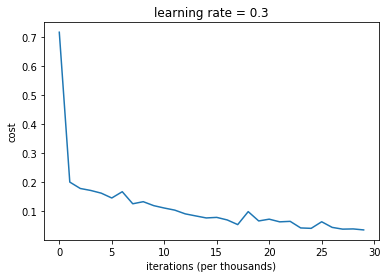

In [20]:
parameters = model(train_X, train_Y, lambd=0, keep_prob = 1.0)

In [21]:
print("on the train set:")  
predictions_train = predict(train_X, train_Y, parameters)  


on the train set:
Accuracy: 0.95260663507109


In [22]:
print("on the test set:")  
predictions_train = predict(test_X, test_Y, parameters)  


on the test set:
Accuracy: 0.92


C:\Users\weido\AppData\Local\Continuum\anaconda3\envs\mypytorch\lib\site-packages\ipykernel_launcher.py:9: RuntimeWarning: overflow encountered in exp
  if __name__ == '__main__':


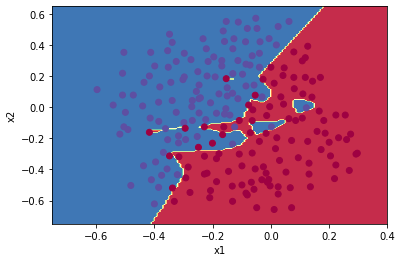

In [23]:
plt.xlim([-0.75, 0.40])  
plt.ylim([-0.75, 0.65])  
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)  


cost after iteration 0: 0.729891795986568
cost after iteration 1000: 0.22038271574448837
cost after iteration 2000: 0.20747342611377909
cost after iteration 3000: 0.2020466661589407
cost after iteration 4000: 0.19855191803396904
cost after iteration 5000: 0.19630492304848154
cost after iteration 6000: 0.19548507528837816
cost after iteration 7000: 0.19250796798482792
cost after iteration 8000: 0.1881160329027946
cost after iteration 9000: 0.18827973257757447
cost after iteration 10000: 0.1783240828651151
cost after iteration 11000: 0.18593997448043503
cost after iteration 12000: 0.17481164385221581
cost after iteration 13000: 0.18046811817551733
cost after iteration 14000: 0.2055959206842671
cost after iteration 15000: 0.17298865089864846
cost after iteration 16000: 0.1725672844529177
cost after iteration 17000: 0.17507961282751688
cost after iteration 18000: 0.20011203038912495
cost after iteration 19000: 0.17293737419534527
cost after iteration 20000: 0.1999770685283905
cost after it

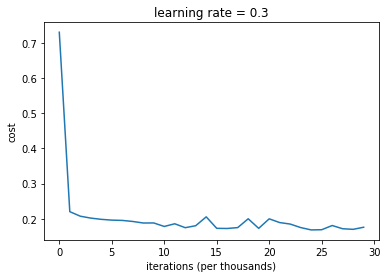

In [24]:
parameters = model(train_X, train_Y, lambd=0.1, keep_prob = 1.0)

In [25]:
print("on the train set:")  
predictions_train = predict(train_X, train_Y, parameters)  


on the train set:
Accuracy: 0.95260663507109


In [26]:
print("on the test set:")  
predictions_train = predict(test_X, test_Y, parameters)  

on the test set:
Accuracy: 0.95


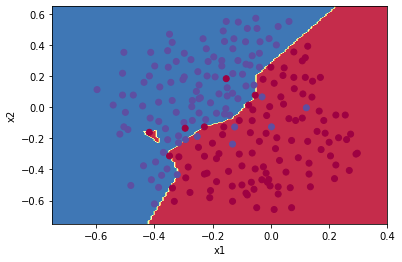

In [27]:
plt.xlim([-0.75, 0.40])  
plt.ylim([-0.75, 0.65])  
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)  


cost after iteration 0: 0.7246627428421546
cost after iteration 1000: 0.15566375811644312


C:\Users\weido\AppData\Local\Continuum\anaconda3\envs\mypytorch\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: divide by zero encountered in log
  
C:\Users\weido\AppData\Local\Continuum\anaconda3\envs\mypytorch\lib\site-packages\ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in multiply
  


cost after iteration 2000: 0.08117861938843758
cost after iteration 3000: 0.05592190366830843
cost after iteration 4000: 0.045114942947660504
cost after iteration 5000: 0.04219548585814692
cost after iteration 6000: 0.04087800359871924
cost after iteration 7000: 0.0402468712881492
cost after iteration 8000: 0.03958085810072377
cost after iteration 9000: 0.03930406034497442
cost after iteration 10000: 0.03906167986203948
cost after iteration 11000: 0.03889519743662013
cost after iteration 12000: 0.03879239145286202
cost after iteration 13000: 0.03868807988125851
cost after iteration 14000: 0.03860245516804406
cost after iteration 15000: 0.03877676820556324
cost after iteration 16000: 0.03856758113727397
cost after iteration 17000: 0.038468621982088204
cost after iteration 18000: 0.03841973374711582
cost after iteration 19000: 0.038389203613451384
cost after iteration 20000: 0.0383594594812885
cost after iteration 21000: 0.038343617273756764
cost after iteration 22000: 0.0383253928717784

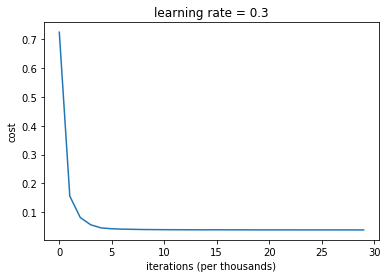

In [28]:
parameters = model(train_X, train_Y, lambd=0, keep_prob = 0.8)

In [29]:
print("on the train set:")  
predictions_train = predict(train_X, train_Y, parameters)  


on the train set:
Accuracy: 0.9241706161137441


In [30]:
print("on the test set:")  
predictions_train = predict(test_X, test_Y, parameters)  

on the test set:
Accuracy: 0.935


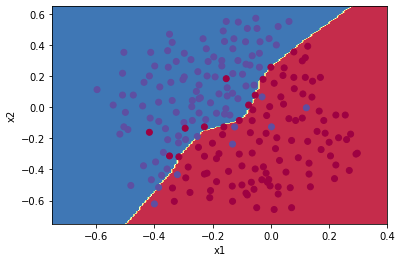

In [31]:
plt.xlim([-0.75, 0.40])  
plt.ylim([-0.75, 0.65])  
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)  
